In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
model = load_model("../models/densenet121_final.h5")

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_DIR = "../data/images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 503 images belonging to 6 classes.


In [8]:
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)


32/32 [==============================] - 59s 2s/step


In [9]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.93      0.78      0.84        80
       glass       0.87      0.84      0.85       100
       metal       0.86      0.93      0.89        82
       paper       0.87      0.94      0.90       118
     plastic       0.82      0.74      0.78        96
       trash       0.69      0.93      0.79        27

    accuracy                           0.85       503
   macro avg       0.84      0.86      0.84       503
weighted avg       0.86      0.85      0.85       503



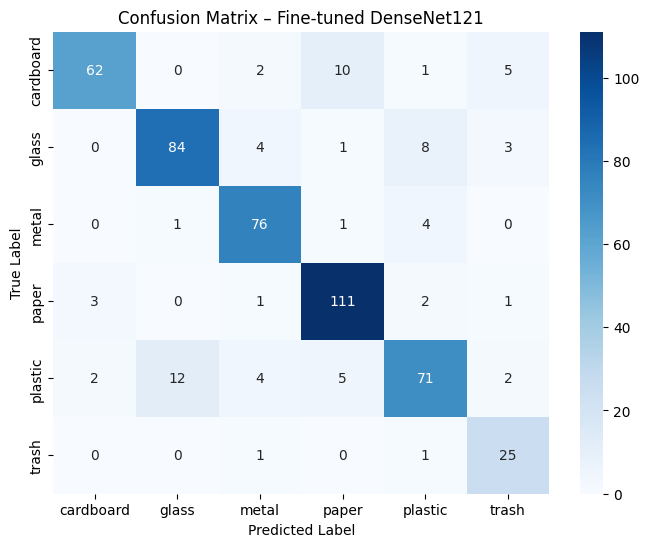

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Fine-tuned DenseNet121")
plt.show()


In [11]:
WASTE_ACTIONS = {
    "cardboard": "Send to recycling facility",
    "paper": "Send to recycling facility",
    "glass": "Handle separately – glass recycling",
    "metal": "Metal recovery process",
    "plastic": "Plastic sorting and recycling",
    "trash": "Send to landfill"
}


In [13]:
def decision_support(predicted_class, confidence):
    action = WASTE_ACTIONS[predicted_class]

    if confidence < 0.6:
        return "Manual inspection required"

    return action


In [14]:
from tensorflow.keras.preprocessing import image

img_path = "../data/images/plastic/plastic32.jpg" 

img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

print("Predicted class:", pred_class)
print("Confidence:", round(confidence, 2))
print("Decision:", decision_support(pred_class, confidence))


1/1 [==============================] - 3s 3s/step
Predicted class: plastic
Confidence: 1.0
Decision: Plastic sorting and recycling
